In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [3]:
prices_raw_2 = pd.read_csv("prices_round_5_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_5_day_3.csv", sep = ";", index_col = "timestamp")
prices_raw_4 = pd.read_csv("prices_round_5_day_4.csv", sep = ";", index_col = "timestamp")
prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw_4.index = prices_raw_4.index + prices_raw_3.index.max() + 100
prices_raw = pd.concat([prices_raw_2, prices_raw_3, prices_raw_4], axis=0)
mid_prices = prices_raw[["product", "mid_price"]]
mid_prices = (
    mid_prices.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)

In [ ]:
sector = mid_prices.filter(regex=r'^MICROCHIP').copy()
log_prices = np.log(sector.loc[1500000:])
a = log_prices.iloc[:, 0]
b = log_prices.iloc[:, 1]
c = log_prices.iloc[:, 2]
d = log_prices.iloc[:, 3]
e = log_prices.iloc[:, 4]
y3 = np.column_stack([b, c, e])
log_prices

product,MICROCHIP_CIRCLE,MICROCHIP_OVAL,MICROCHIP_RECTANGLE,MICROCHIP_SQUARE,MICROCHIP_TRIANGLE
timestamp,,,,,
2500000,9.165604,8.714321,9.066816,9.694617,9.044994
2500100,9.163092,8.714896,9.067278,9.694247,9.045819
2500200,9.165709,8.714075,9.066008,9.694555,9.045466
2500300,9.166075,8.713253,9.065083,9.695664,9.045996
2500400,9.166179,8.715060,9.064505,9.694647,9.044758
...,...,...,...,...,...
2999500,9.243630,8.611048,9.084210,9.521055,8.979732
2999600,9.243146,8.611321,9.081256,9.521128,8.981430
2999700,9.245804,8.613230,9.079434,9.519368,8.978850


In [70]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(y3, 0, 10)
print("Trace Statistic: \n", result.lr1)
print("Trace Critical Values: \n", result.cvt)
print("Max Eigenvalue Statistic: \n", result.lr2)
print("Max Eigenvalue Critical Values: \n", result.cvm)

Trace Statistic: 
 [18.58360292  3.30048563  1.04301386]
Trace Critical Values: 
 [[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max Eigenvalue Statistic: 
 [15.28311729  2.25747177  1.04301386]
Max Eigenvalue Critical Values: 
 [[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [71]:
beta = result.evec[:, 0]
beta

array([ 30.0947302 ,  -6.37193935, -58.51220936])

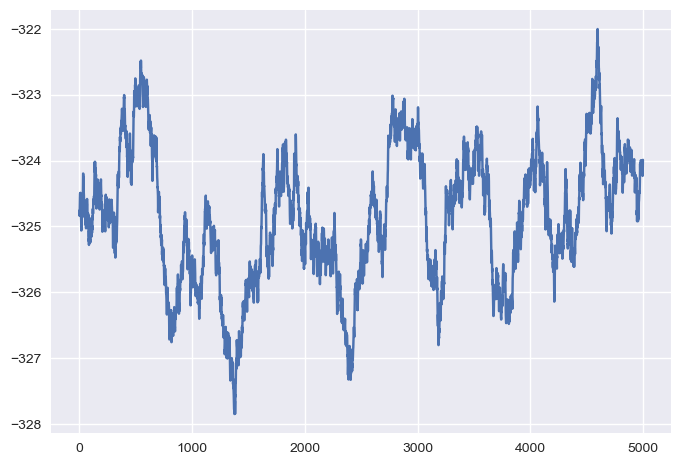

In [72]:
spread = y3 @ beta
plt.plot(spread)

In [73]:
import statsmodels.tsa.stattools as ts
cadf = ts.adfuller(spread)
print ('Augmented Dickey Fuller test statistic =',cadf[0])
print ('Augmented Dickey Fuller p-value =',cadf[1])
print ('Augmented Dickey Fuller 1%, 5% and 10% test statistics =',cadf[4])

Augmented Dickey Fuller test statistic = -3.368248511302229
Augmented Dickey Fuller p-value = 0.012090090478837941
Augmented Dickey Fuller 1%, 5% and 10% test statistics = {'1%': np.float64(-3.431658793968827), '5%': np.float64(-2.862118345383404), '10%': np.float64(-2.567077853953267)}


In [74]:
spread.mean()

np.float64(-324.87657764055444)

In [75]:
spread.std()

np.float64(1.0155772889201797)

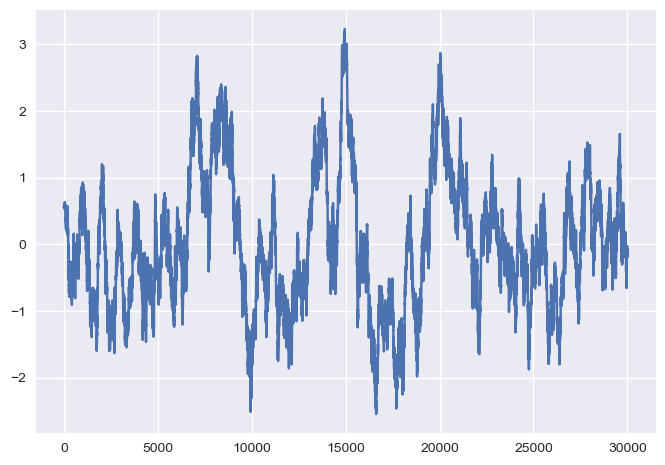

In [52]:
z_spread = (spread - spread.mean()) / spread.std()
plt.plot(z_spread)